***
# KWS (keyword spotting) and applying for EFR32FG24 Silicon lab kit
***
- peiman edalatjoo -  *** KWS_ver01.07 *** - winter 2025 - HKA
- Any correction, enhancement, or guidance reported to peiman.edalatjoo@proton.me or edpe1011@h-ka.de will be greatly appreciated.
- To run this code error-free, please read the README file first.
- Also there is Useful-Notes file that I suggest you to read when you get some progress.
***
Description:
An audio dataset of spoken words designed to help train and evaluate keyword spotting systems. Its primary goal is to provide a way to build and test small models that detect when a single word is spoken, from a set of ten target words, with as few false positives as possible from background noise or unrelated speech. Note that in the train and validation set, the label "unknown" is much more prevalent than the labels of the target words or background noise. One difference from the release version is the handling of silent segments. While in the test set the silence segments are regular 1 second files, in the training they are provided as long segments under "background_noise" folder. Here we split these background noise into 1 second clips, and also keep one of the files for the validation set. https://www.tensorflow.org/datasets/catalog/speech_commands

### Ver_1.07 (comparison with previous version Ver_1.06)

Model optimised -  Methodes BatchNormalization() ReduceLROnPlateau() added -   

| Feature/Metric                | Ver_1.05                | Ver_1.06                | Ver_1.07 (KWS7)           |
|-------------------------------|-------------------------|-------------------------|---------------------------|
| RandomSearch max_trials       | 10                      | 20                      | 15                        |
| executions_per_trial          | 1                       | 3                       | 1                         |
| EarlyStopping patience        | 3                       | 5                       | 5                         |
| EarlyStopping min_delta       | —                       | 0.001                   | 0.01                      |
| BatchNormalization            | —                       | —                       | Yes                       |
| ReduceLROnPlateau             | —                       | —                       | Yes                       |
| Total params                  | 4,972 (19.42 KB)        | 28,684 (112.05 KB)      | 24140 (94.30 KB)          |
| val_accuracy                  | 0.7142                  | 0.7623                  | 0.932                     |
| Accuracy F1                   | 0.70                    | 0.90                    | 0.88                      |
| model.tflite size             | 30 KB                   | 35 KB                   | 32 KB                     |


## 1- Import datasets - Data preparation
### 1.1: Import the Dataset
- We will use TensorFlow Datasets (tensorflow_datasets) to load the Google Speech Commands dataset.

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Set seeds for reproducibility. By setting the same seed value, you ensure that your experiments (such as model training and /
# data shuffling) produce the same results each time you run the code, which is important for debugging and comparing results.
def set_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)

The command tfds.load('speech_commands', with_info=True, as_supervised=True) downloads the Speech Commands dataset from the official TFDS repository: https://www.tensorflow.org/datasets/catalog/speech_commands.

In the cell below, the downloaded data will be saved to your current path within the save_dir = 'saved_speech_commands' directory. It will be organized into separate subdirectories: test, train, and validation. You are free to change these names and paths as desired. If the data already exists on your local hard drive, it will be loaded from there instead of being re-downloaded.

Explanation of Pickle:

The info object returned by tfds.load() contains crucial metadata about the dataset, such as label names, sample rate, and other valuable information.

This info object is not a simple data type (like a string or list); rather, it is a complex Python object. To save this object for later use (avoiding the need to reload and reconstruct it every time), pickle.dump() is employed. This function serializes the information and writes it to a file. Conversely, pickle.load() is used to read this serialized information from a file, restoring the info object to its original state.

In [2]:

def save_dataset(dataset, path):
    tf.data.Dataset.save(dataset, path)

def load_dataset(path):
    #return tf.data.experimental.load(path)
    return tf.data.Dataset.load(path)
# Paths to save datasets
save_dir = 'saved_speech_commands'
train_path = os.path.join(save_dir, 'train')
val_path = os.path.join(save_dir, 'validation')
test_path = os.path.join(save_dir, 'test')
info_path = os.path.join(save_dir, 'info.pkl')

# Create save directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Check if saved datasets exist
if all(os.path.exists(p) for p in [train_path, val_path, test_path, info_path]):
    print('Loading datasets from disk...')
    train_dataset = load_dataset(train_path)
    validation_dataset = load_dataset(val_path)
    test_dataset = load_dataset(test_path)
    with open(info_path, 'rb') as f:
        info = pickle.load(f)
else:
    print('Loading datasets from TensorFlow Datasets...')
    dataset, info = tfds.load('speech_commands', with_info=True, as_supervised=True)
    #as_supervised=True to get (input, label) pairs instead of a dictionary.
    #return additional metadata (info) about the dataset if you set with_info=True
    train_dataset = dataset['train']
    validation_dataset = dataset['validation']
    test_dataset = dataset['test']
    save_dataset(train_dataset, train_path)
    save_dataset(validation_dataset, val_path)
    save_dataset(test_dataset, test_path)
    with open(info_path, 'wb') as f:
        pickle.dump(info, f)
    print('Datasets saved to disk.')

print(f"Number of training samples: {len(list(train_dataset))}")
print(f"Number of validation samples: {len(list(validation_dataset))}")
print(f"Number of test samples: {len(list(test_dataset))}")
print(f"Available labels: {info.features['label'].names}")
print("Dataset Info:")
print(info)


Loading datasets from disk...
Number of training samples: 106497
Number of validation samples: 121
Number of test samples: 4890
Available labels: ['down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up', 'yes', '_silence_', '_unknown_']
Dataset Info:
tfds.core.DatasetInfo(
    name='speech_commands',
    full_name='speech_commands/0.0.3',
    description="""
    An audio dataset of spoken words designed to help train and evaluate keyword
    spotting systems. Its primary goal is to provide a way to build and test small
    models that detect when a single word is spoken, from a set of ten target words,
    with as few false positives as possible from background noise or unrelated
    speech. Note that in the train and validation set, the label "unknown" is much
    more prevalent than the labels of the target words or background noise. One
    difference from the release version is the handling of silent segments. While in
    the test set the silence segments are regular 1 seco

- Shape and Datatype of downloaded dtatsets
Regarding the output of the code below, the saved datasets are tuples (x0, x1) or (x, y) where x0 and x1 are TensorFlow objects. x0 is the sample and x1 its lable. numpy(x0) is a one-dimensional array (16000,) which stores a 1-second audio sample at 16,000 samples per second. Each sample is int16 (two bytes). x1 or y is the lable number of dataset ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go', 'unknown', 'silence'].  :) good! 

In [15]:
# Load dataset and print audio shape with label name
# Load label names from info.pkl
with open('saved_speech_commands/info.pkl', 'rb') as f:
    info = pickle.load(f)
label_names = info.features['label'].names

print("Training dataset datatypes check:")   
for x in train_dataset.take(1):
    print(type(x))              # <class 'tuple'>
    print(type(x[0]), x[0].shape, x[0].dtype)  # audio tensor
    print(type(x[1]), x[1].numpy())            # label tensor
print("Validation dataset datatypes check:")    
for x in validation_dataset.take(1):
    print(type(x))              # <class 'tuple'>
    print(type(x[0]), x[0].shape, x[0].dtype)  # audio tensor
    print(type(x[1]), x[1].numpy())            # label tensor
print("Test dataset datatypes check:")
for x in test_dataset.take(1):
    print(type(x))              # <class 'tuple'>
    print(type(x[0]), x[0].shape, x[0].dtype)  # audio tensor
    print(type(x[1]), x[1].numpy())            # label tensor 




Training dataset datatypes check:
<class 'tuple'>
<class 'tensorflow.python.framework.ops.EagerTensor'> (16000,) <dtype: 'int16'>
<class 'tensorflow.python.framework.ops.EagerTensor'> 4
Validation dataset datatypes check:
<class 'tuple'>
<class 'tensorflow.python.framework.ops.EagerTensor'> (16000,) <dtype: 'int16'>
<class 'tensorflow.python.framework.ops.EagerTensor'> 10
Test dataset datatypes check:
<class 'tuple'>
<class 'tensorflow.python.framework.ops.EagerTensor'> (16000,) <dtype: 'int16'>
<class 'tensorflow.python.framework.ops.EagerTensor'> 7


### 1-2 Evaluating -  data engineering

- Dataset quility

Note: The output below shows that the Validation Datasets contain only silent samples. We will need to handle this later in the code.
It's a good idea to investigate what "silent" means — is it zero (i.e., complete silence or no signal at all)?
We should also check if the data is flat (i.e., no variation in amplitude). If so, such samples should be removed.

In [4]:
def print_audio_sample_quality(dataset, label_names):
    silent_counts = {name: 0 for name in label_names}
    flat_counts = {name: 0 for name in label_names}
    nan_counts = {name: 0 for name in label_names}
    total_counts = {name: 0 for name in label_names}
    total_samples = 0
    for audio, label in dataset:
        audio_np = audio.numpy() if hasattr(audio, 'numpy') else np.array(audio)
        label_name = label_names[label.numpy()]
        total_counts[label_name] += 1
        total_samples += 1
        if np.all(audio_np == 0): # check if all values are zero (silent)
            silent_counts[label_name] += 1
        if np.all(audio_np == audio_np[0]): # check if all values are the same (flat)
            flat_counts[label_name] += 1
        if np.any(np.isnan(audio_np)) or np.any(np.isinf(audio_np)): # check for NaN (Not a numbe) or +/- Infinit values
            nan_counts[label_name] += 1
    print(f"Total samples in dataset: {total_samples}")
    print("Label\tTotal\tSilent\tFlat\tNaN/Inf")
    for name in label_names:
        print(f"{name}\t{total_counts[name]}\t{silent_counts[name]}\t{flat_counts[name]}\t{nan_counts[name]}")

# Example usage:
print("Train dataset sample quality:")
print_audio_sample_quality(train_dataset, label_names)
print("\nValidation dataset sample quality:")
print_audio_sample_quality(validation_dataset, label_names)
print("\nTest dataset sample quality:")
print_audio_sample_quality(test_dataset, label_names)
#print(f"Number of samples in train dataset: {len(list(train_dataset))}")


Train dataset sample quality:
Total samples in dataset: 106497
Label	Total	Silent	Flat	NaN/Inf
down	3917	0	0	0
go	3880	0	0	0
left	3801	0	0	0
no	3941	0	0	0
off	3745	0	0	0
on	3845	0	0	0
right	3778	0	0	0
stop	3872	0	0	0
up	3723	0	0	0
yes	4044	0	0	0
_silence_	668	0	0	0
_unknown_	67283	0	0	0

Validation dataset sample quality:
Total samples in dataset: 121
Label	Total	Silent	Flat	NaN/Inf
down	0	0	0	0
go	0	0	0	0
left	0	0	0	0
no	0	0	0	0
off	0	0	0	0
on	0	0	0	0
right	0	0	0	0
stop	0	0	0	0
up	0	0	0	0
yes	0	0	0	0
_silence_	121	0	0	0
_unknown_	0	0	0	0

Test dataset sample quality:
Total samples in dataset: 4890
Label	Total	Silent	Flat	NaN/Inf
down	406	0	0	0
go	402	0	0	0
left	412	0	0	0
no	405	0	0	0
off	402	0	0	0
on	396	0	0	0
right	396	0	0	0
stop	411	0	0	0
up	425	0	0	0
yes	419	0	0	0
_silence_	408	0	0	0
_unknown_	408	0	0	0


###  Shape of audio samples - Sampling Rate (SR)
- As seen in the output of below cell, just SR of training dataset varies from 16000 Hz. Two others are fixed 16000.

Note: as we are samples are humance voice so according Nyquist rate, 16kz will fulfill to cover human voice range of frequency.

In [5]:
#print out min, max of the shape of audio samples for each dataset (train, validation, test)
def print_audio_shape_stats(dataset, dataset_name):
    shapes = [audio.shape for audio, _ in dataset]
    min_shape = min(shapes, key=lambda x: x[0])
    max_shape = max(shapes, key=lambda x: x[0])
    print(f"{dataset_name} dataset audio shape stats:")
    print(f"Min shape: {min_shape}")
    print(f"Max shape: {max_shape}")
print_audio_shape_stats(train_dataset, "Train")
print_audio_shape_stats(validation_dataset, "Validation")   
print_audio_shape_stats(test_dataset, "Test")

Train dataset audio shape stats:
Min shape: (3413,)
Max shape: (16000,)
Validation dataset audio shape stats:
Min shape: (16000,)
Max shape: (16000,)
Test dataset audio shape stats:
Min shape: (16000,)
Max shape: (16000,)


Plotting audio length boxplot per label for training dataset...


C:\Users\Peyman\AppData\Local\Temp\ipykernel_900\1877108847.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=label_names, showmeans=True)


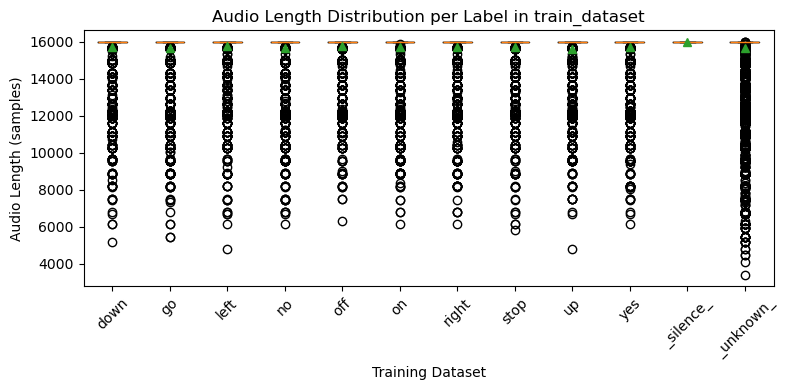

In [6]:
def plot_audio_length_boxplot_per_label(dataset, label_names, dataset_name):
    lengths_per_label = {name: [] for name in label_names}
    for audio, label in dataset:
        label_name = label_names[label.numpy()]
        lengths_per_label[label_name].append(audio.shape[0])
    data = [lengths_per_label[name] for name in label_names]
    plt.figure(figsize=(8, 4))
    plt.boxplot(data, labels=label_names, showmeans=True)
    plt.xlabel(dataset_name)
    plt.ylabel('Audio Length (samples)')
    plt.title('Audio Length Distribution per Label in train_dataset')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# plotting the audio length boxplot per label for training dataset
print("Plotting audio length boxplot per label for training dataset...")    
plot_audio_length_boxplot_per_label(train_dataset, label_names, 'Training Dataset')



- ploting one non-16k and one 16khz of train and two random of the others to visualise amplitude and shape of datasets we have! take note to the silence shape!

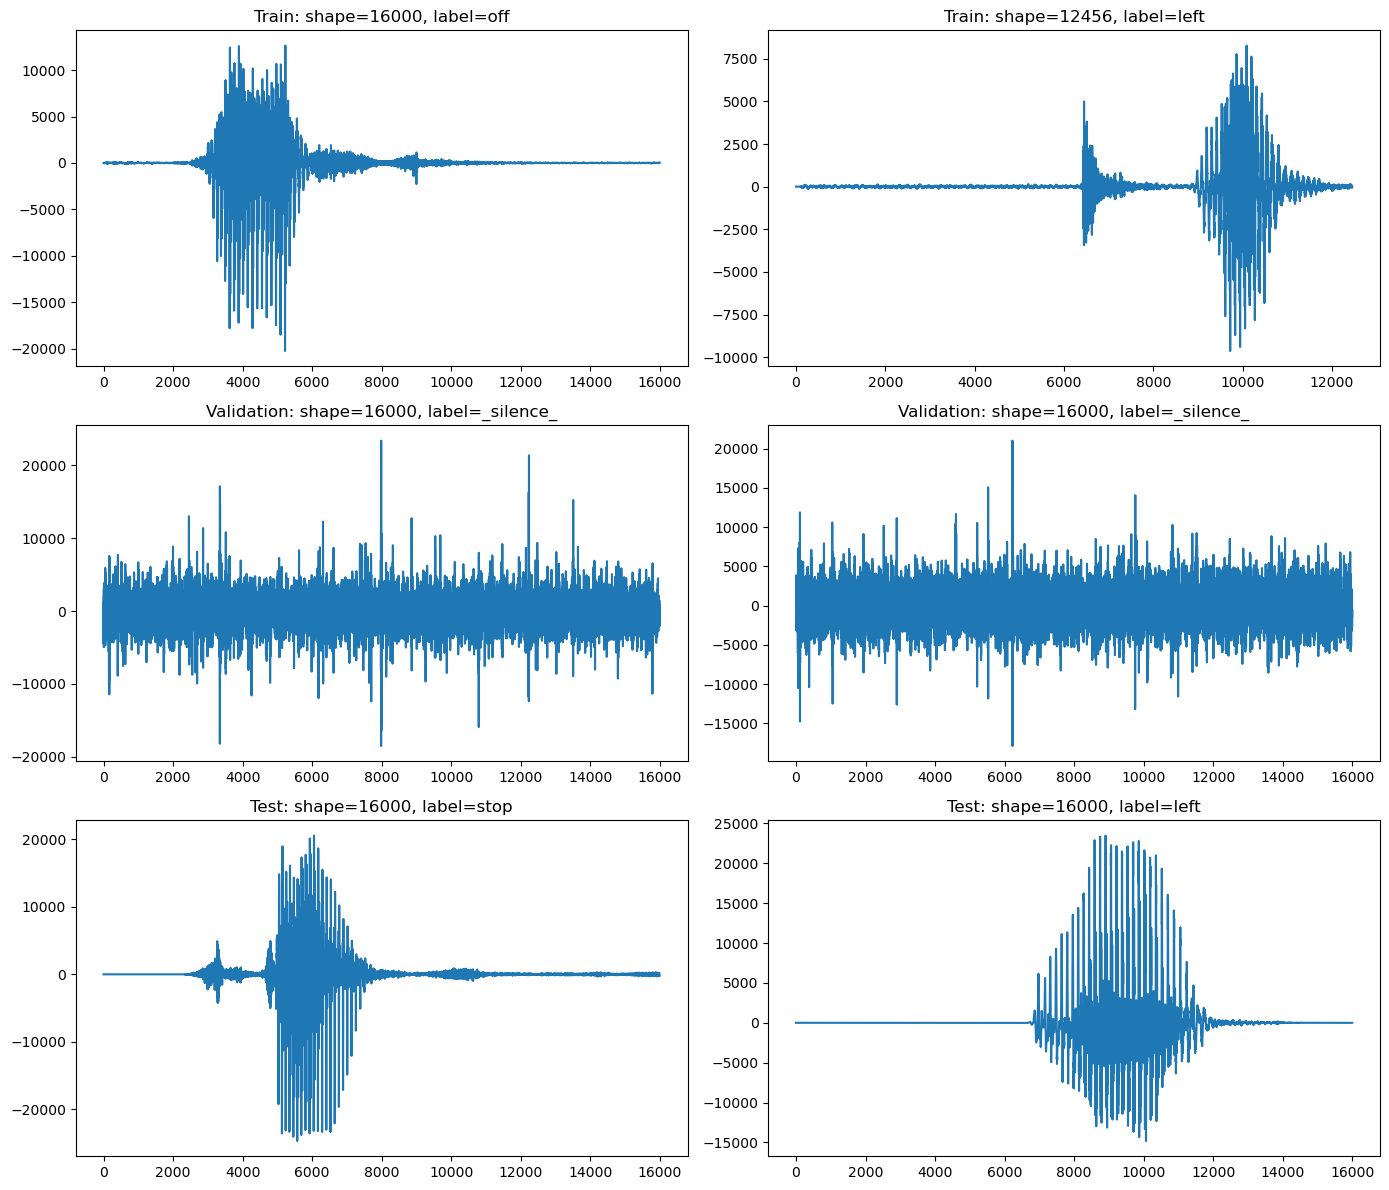

In [7]:

# Helper to get one sample of a given length from a dataset
def get_sample_by_length(dataset, length, exclude=False):
    for audio, label in dataset:
        if (audio.shape[0] == length) != exclude:
            return audio.numpy(), label.numpy()
    return None, None

# Get one 16000-shape and one non-16000-shape from train_dataset
audio_16000, label_16000 = get_sample_by_length(train_dataset, 16000, exclude=False)
audio_non16000, label_non16000 = get_sample_by_length(train_dataset, 16000, exclude=True)

# Get two random samples from validation_dataset
val_samples = [(audio.numpy(), label.numpy()) for audio, label in validation_dataset.take(2)]

# Get two random samples from test_dataset
test_samples = [(audio.numpy(), label.numpy()) for audio, label in test_dataset.take(2)]


# Adjust to 3 rows and 2 columns: first row - training, second - validation, third - test
fig, axs = plt.subplots(3, 2, figsize=(14, 12))

# Training samples
axs[0, 0].plot(audio_16000)
axs[0, 0].set_title(f"Train: shape=16000, label={label_names[label_16000]}")
axs[0, 1].plot(audio_non16000)
axs[0, 1].set_title(f"Train: shape={audio_non16000.shape[0]}, label={label_names[label_non16000]}")

# Validation samples
axs[1, 0].plot(val_samples[0][0])
axs[1, 0].set_title(f"Validation: shape={val_samples[0][0].shape[0]}, label={label_names[val_samples[0][1]]}")
axs[1, 1].plot(val_samples[1][0])
axs[1, 1].set_title(f"Validation: shape={val_samples[1][0].shape[0]}, label={label_names[val_samples[1][1]]}")

# Test samples
axs[2, 0].plot(test_samples[0][0])
axs[2, 0].set_title(f"Test: shape={test_samples[0][0].shape[0]}, label={label_names[test_samples[0][1]]}")
axs[2, 1].plot(test_samples[1][0])
axs[2, 1].set_title(f"Test: shape={test_samples[1][0].shape[0]}, label={label_names[test_samples[1][1]]}")
# print the shape of an example of _unknown_ lable from training and validation datasets  

plt.tight_layout()
plt.show()

### Extracting Validation Dataset from Training Dataset

As explained earlier, the validation dataset consists only of silent labels (samples). To ensure the training model works correctly, the validation set needs to be reconstructed.

In this initial approach, we extract it from the training dataset.

Also since we are using a CNN model, which expects fixed-dimensional, image-like input. As we evaluated alreadys, some of training dataset samples are less than 16000 so we reshape those by zero-padding to a fixed size of 16,000 samples (1 second recording at 16 kHz).The test dataset is already at 16 kHz and will remain unchanged.

In order to split evently it has been used train_test_split method from sklearn with stratify=y which I was familliar with. There might be another method from Tensorflow with same function you can use. I am not sure!

In [3]:
from sklearn.model_selection import train_test_split

X = []
y = []
desired_len = 16000  # or whatever fixed length you want

for audio, label in train_dataset:
    audio_np = audio.numpy()
    if len(audio_np) < desired_len:
        audio_np = np.pad(audio_np, (0, desired_len - len(audio_np)))
    else:
        audio_np = audio_np[:desired_len]
    X.append(audio_np)
    y.append(label.numpy())

X = np.array(X)
y = np.array(y)

# Now you can use train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)   #  stratify=y ensures that the split maintains the same distribution of labels
# test_size=0.1, 10 percent of the training data will be used for validation


new_train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
new_validation_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))

- Verify that the datasets include diversity of samples.

In [4]:


# Helper function to count label occurrences in a tf.data.Dataset

def count_labels(dataset, label_names):
    counts = {name: 0 for name in label_names}
    for _, label in dataset:
        label_idx = int(label.numpy())
        counts[label_names[label_idx]] += 1
    return counts

# Count labels in each dataset
train_counts = count_labels(new_train_dataset, label_names)
val_counts = count_labels(new_validation_dataset, label_names)
test_counts = count_labels(test_dataset, label_names)

# Create a DataFrame to display as a table
df_counts = pd.DataFrame({
    'Train': pd.Series(train_counts),
    'Validation': pd.Series(val_counts),
    'Test': pd.Series(test_counts)
}).fillna(0).astype(int)

# Add total row
df_counts.loc['Total'] = df_counts.sum()

print(df_counts)




NameError: name 'label_names' is not defined

- Printing 5 random samples from each dataset.

In [ ]:
# Print 5 random samples from each dataset
print("5 random samples from Training Dataset:")
for audio, label in new_train_dataset.shuffle(10000).take(5):
    print(audio.shape, label.numpy(), label_names[label.numpy()])
print("Audio dtype:", audio.dtype)

print("5 random samples from Validation Dataset:")
for audio, label in new_validation_dataset.shuffle(10000).take(5):
    print(audio.shape, label.numpy(), label_names[label.numpy()])
print("Audio dtype:", audio.dtype)

print("5 random samples from Test Dataset:")
for audio, label in test_dataset.shuffle(10000).take(5):
    print(audio.shape, label.numpy(), label_names[label.numpy()])
print("Audio dtype:", audio.dtype)
# print(f"Audio sample rate: {info.features['audio'].sample_rate}")

5 random samples from Training Dataset:
(16000,) 11 _unknown_
(16000,) 7 stop
(16000,) 1 go
(16000,) 11 _unknown_
(16000,) 8 up
Audio dtype: <dtype: 'int16'>
5 random samples from Validation Dataset:
(16000,) 2 left
(16000,) 11 _unknown_
(16000,) 6 right
(16000,) 11 _unknown_
(16000,) 11 _unknown_
Audio dtype: <dtype: 'int16'>
5 random samples from Test Dataset:


In [5]:
#print out min, max of the shape of audio samples for each dataset (train, validation, test)
#  to make sure they are all 16000 samples long
def print_audio_shape_stats(dataset, dataset_name):
    shapes = [audio.shape for audio, _ in dataset]
    min_shape = min(shapes, key=lambda x: x[0])
    max_shape = max(shapes, key=lambda x: x[0])
    print(f"{dataset_name} dataset audio shape stats:")
    print(f"Min shape: {min_shape}")
    print(f"Max shape: {max_shape}")
print_audio_shape_stats(new_train_dataset, "Train")
print_audio_shape_stats(new_validation_dataset, "Validation")   
print_audio_shape_stats(test_dataset, "Test")

Train dataset audio shape stats:
Min shape: (16000,)
Max shape: (16000,)
Validation dataset audio shape stats:
Min shape: (16000,)
Max shape: (16000,)
Test dataset audio shape stats:
Min shape: (16000,)
Max shape: (16000,)


- Sample Rate Distribution of audio samples in each data set.

Plotting audio length boxplot per label for training dataset...


C:\Users\Peyman\AppData\Local\Temp\ipykernel_16536\4071746973.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=label_names, showmeans=True)


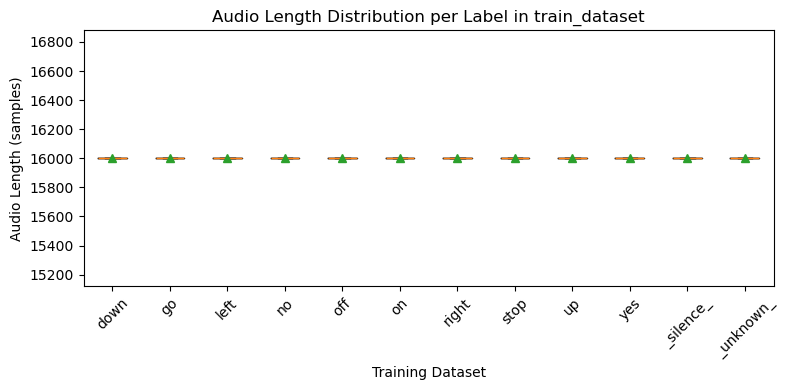

Plotting audio length boxplot per label for validation dataset...


C:\Users\Peyman\AppData\Local\Temp\ipykernel_16536\4071746973.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=label_names, showmeans=True)


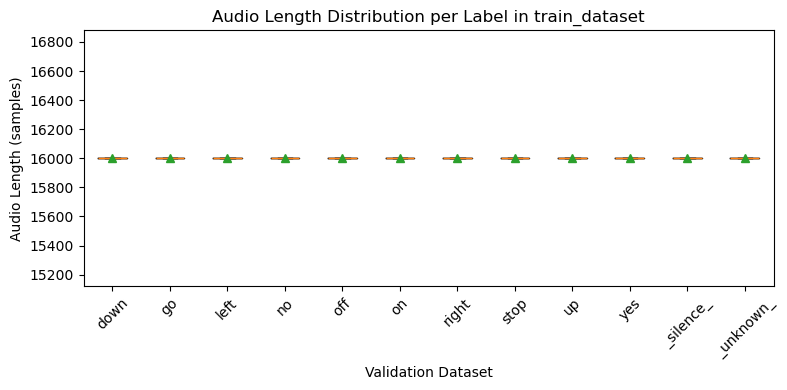

Plotting audio length boxplot per label for test dataset...


C:\Users\Peyman\AppData\Local\Temp\ipykernel_16536\4071746973.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=label_names, showmeans=True)


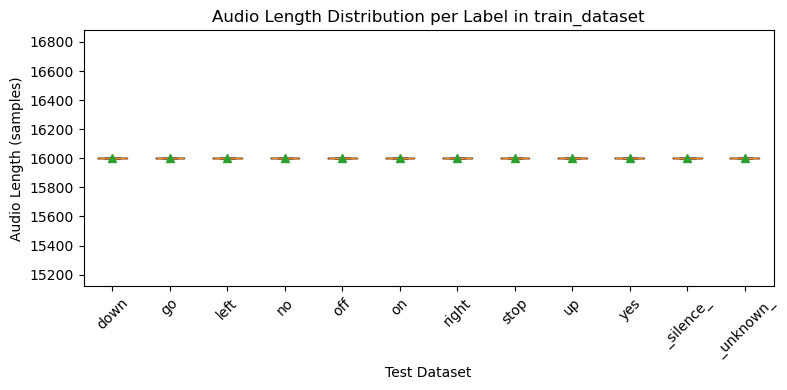

In [ ]:
def plot_audio_length_boxplot_per_label(dataset, label_names, dataset_name):
    lengths_per_label = {name: [] for name in label_names}
    for audio, label in dataset:
        label_name = label_names[label.numpy()]
        lengths_per_label[label_name].append(audio.shape[0])
    data = [lengths_per_label[name] for name in label_names]
    plt.figure(figsize=(8, 4))
    plt.boxplot(data, labels=label_names, showmeans=True)
    plt.xlabel(dataset_name)
    plt.ylabel('Audio Length (samples)')
    plt.title('Audio Length Distribution per Label in train_dataset')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Example usage:
print("Plotting audio length boxplot per label for training dataset...")    
plot_audio_length_boxplot_per_label(new_train_dataset, label_names, 'Training Dataset')
print("Plotting audio length boxplot per label for validation dataset...")    
plot_audio_length_boxplot_per_label(new_validation_dataset, label_names, 'Validation Dataset')
print("Plotting audio length boxplot per label for test dataset...")    
plot_audio_length_boxplot_per_label(test_dataset, label_names, 'Test Dataset')



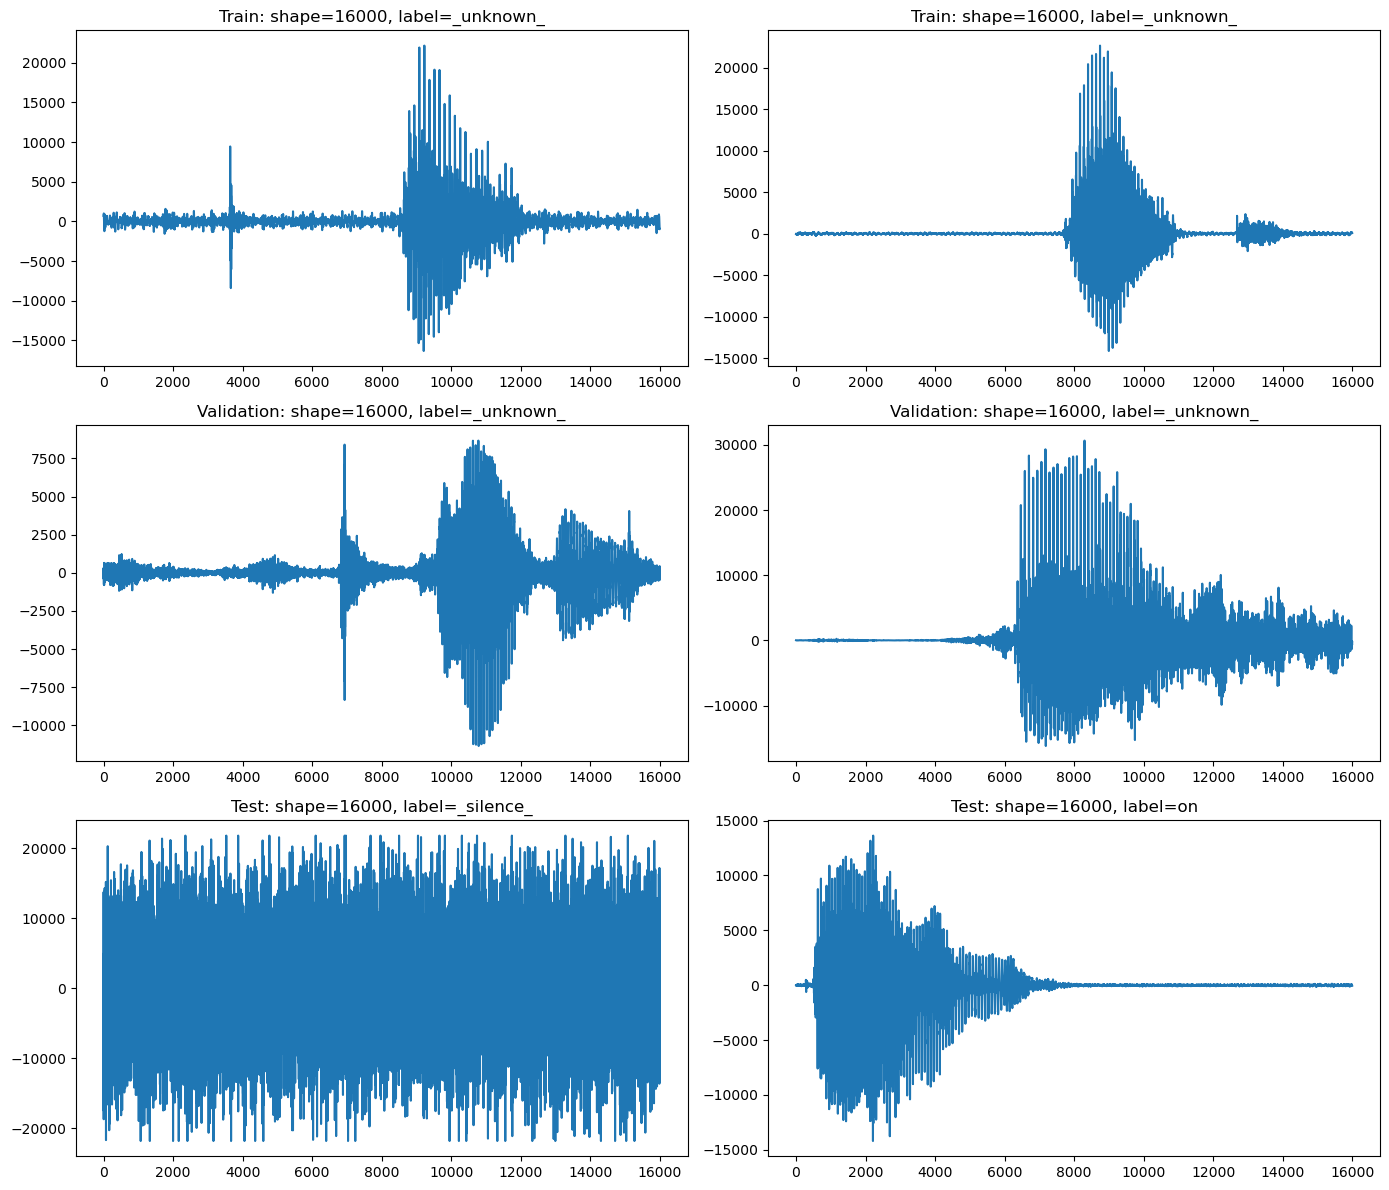

In [ ]:
def plot_two_samples_per_dataset(datasets, dataset_names, label_names):
    """
    Plots 2 random samples from each dataset in a 3x2 subplot grid.
    Args:
        datasets: list of tf.data.Dataset objects (length 3)
        dataset_names: list of str, names for each dataset (length 3)
        label_names: list of label names for decoding label indices
    """
    fig, axs = plt.subplots(3, 2, figsize=(14, 12))
    for row, (ds, name) in enumerate(zip(datasets, dataset_names)):
        # Convert dataset to list for random sampling
        samples = list(ds)
        idxs = np.random.choice(len(samples), 2, replace=False)
        for col, idx in enumerate(idxs):
            audio, label = samples[idx]
            axs[row, col].plot(audio.numpy())
            axs[row, col].set_title(f"{name}: shape={audio.shape[0]}, label={label_names[label.numpy()]}")
    plt.tight_layout()
    plt.show()

# Example usage:
plot_two_samples_per_dataset(
    [new_train_dataset, new_validation_dataset, test_dataset],
    ['Train', 'Validation', 'Test'],
    label_names
)

# 2-Preprocess the Data
We have evaluated our datasets. Now, we need to perform additional preprocessing.
Since we already applied equalization during validation data extraction, here we normalize the samples — as expected in multilabel classification data processing

### 2-1 Normalising

In [6]:

def preprocess_audio(audio, label):
    # Normalize audio to range [-1, 1]
    audio = tf.cast(audio, tf.float32) / tf.int16.max
    return audio, label

# Apply preprocessing to the datasets
#  tf.image.resize_with_crop_or_pad expects a 3D or 4D tensor (image), /
# but audio is a 1D tensor. For 1D audio, use tf.cond with tf.shape or tf.pad/tf.slice directly.
# It is a good practice to keep the original/raw datasets unchanged and save the preprocessed datasets in new variables.
# This allows you to reuse the raw data for different preprocessing or experiments.

train_dataset_Nor_Padded= new_train_dataset.map(preprocess_audio)
validation_dataset_Nor_Padded = new_validation_dataset.map(preprocess_audio)
test_dataset_Nor_Padded = test_dataset.map(preprocess_audio)

 

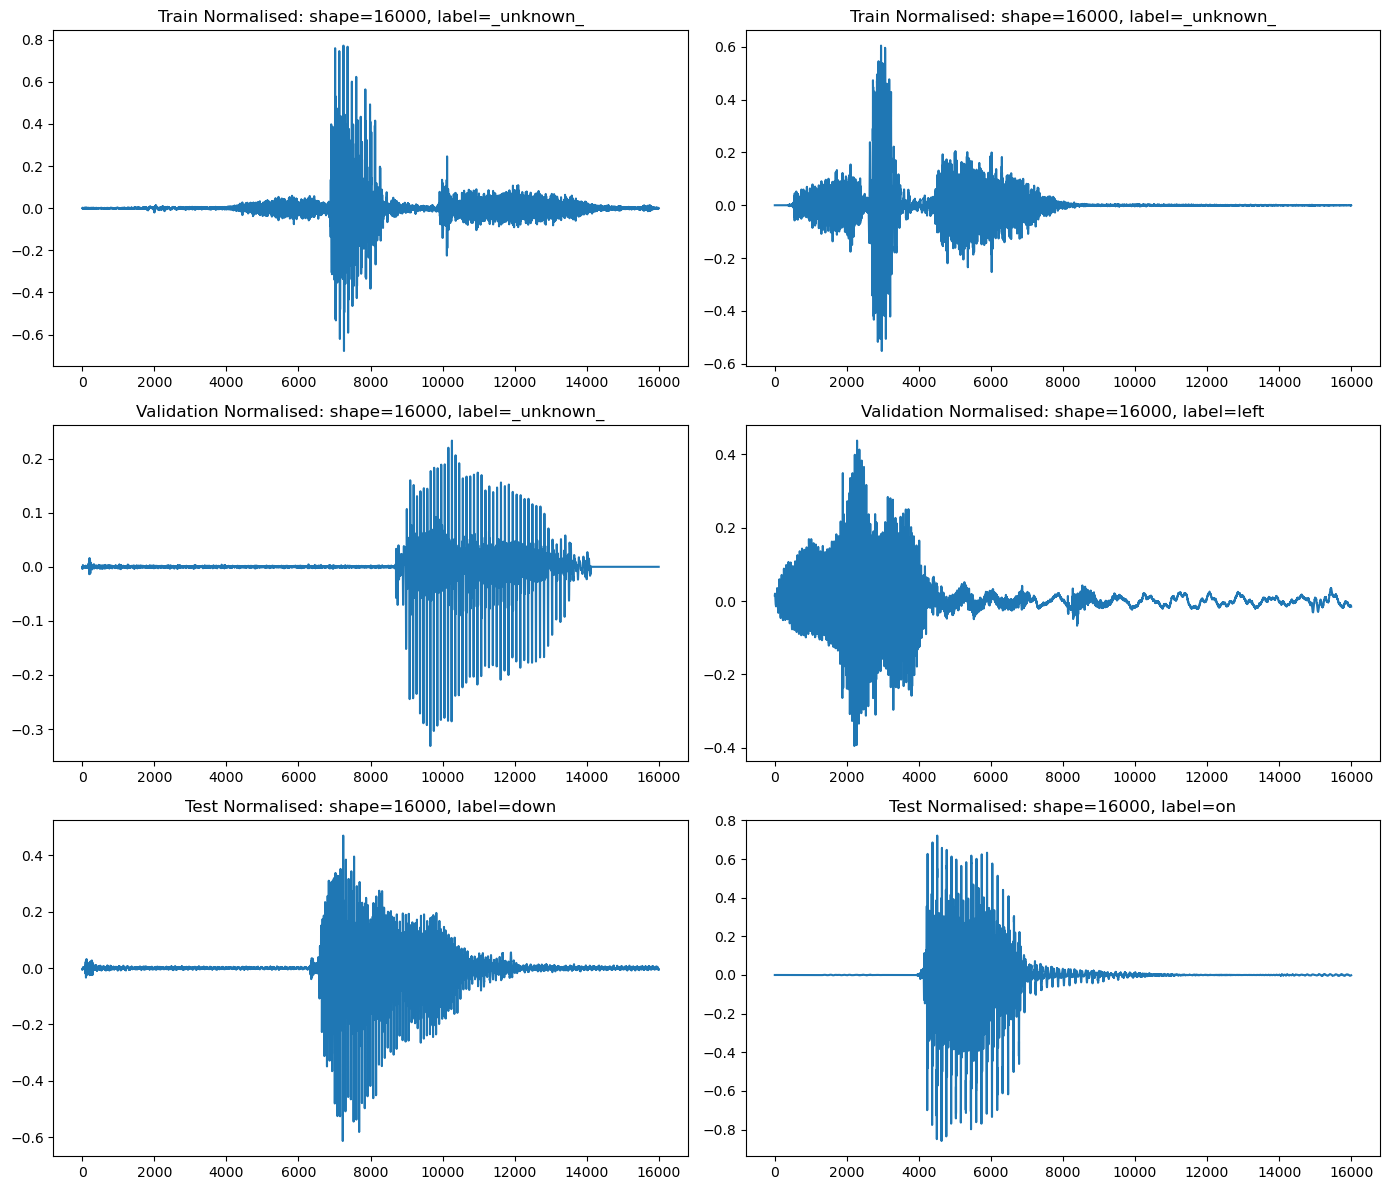

In [ ]:
plot_two_samples_per_dataset(
    [train_dataset_Nor_Padded, validation_dataset_Nor_Padded, test_dataset_Nor_Padded],
    ['Train Normalised', 'Validation Normalised', 'Test Normalised'],
    label_names
)

- Verify the Dataset
To ensure everything is working as expected, let's inspect the dataset and visualize some samples:

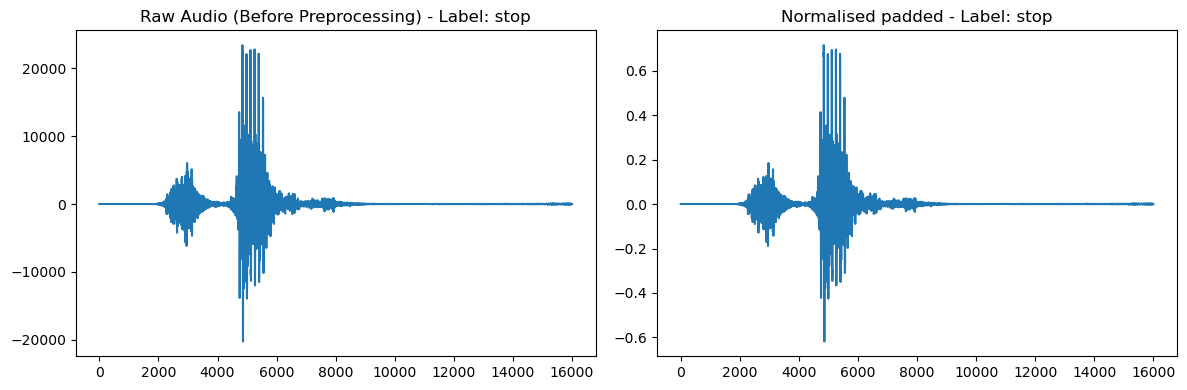

In [ ]:

'''ds = tf.data.experimental.load('saved_speech_commands/train')    raw_audio, raw_label = next(iter(ds))
# Get the first raw audio sample and its label from the original dataset
raw_audio, raw_label = next(iter(ds))'''

# Get the first raw audio sample and its label from the original dataset
raw_audio, raw_label = next(iter(new_train_dataset))

# Get the first preprocessed audio sample and its label from the preprocessed dataset
preprocessed_audio, preprocessed_label = next(iter(train_dataset_Nor_Padded))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(raw_audio.numpy())
plt.title(f"Raw Audio (Before Preprocessing) - Label: {label_names[raw_label.numpy()]}")

plt.subplot(1, 2, 2)
plt.plot(preprocessed_audio.numpy())
plt.title(f"Normalised padded - Label: {label_names[preprocessed_label.numpy()]}")

plt.tight_layout()
plt.show()

### 2-2 **Prepare data for CNN**
 **Extract Features**:
- Convert audio to spectrogram using STFT
- Map it to the mel scale
- Apply log scaling
- Extract the first 13 MFCCs per frame as features
- These features will serve as input to the CNN.

STFT (Short-Time Fourier Transform):
STFT breaks the audio signal into short overlapping frames to show how frequency content changes over time — this gives us a spectrogram.
It works by dividing the audio into smaller time windows and computing the frequency content of each frame.
In other words, we produce a sequence of time–frequency images, where each frame represents the spectrum at a specific moment.we typically take the magnitude (absolute value) of it.This gives us the energy or intensity of each frequency component in each frame, which forms the spectrogram. The output result of transform of one dimentional a 16000 data sample is two dimentional data consists of (x,y) where x is number of time slots as a result of sweeping defined window-lengh over a sample and frequency bins in that time slot and z is frequency bins. after pathing through this data from MFCC algorithem and keeping just the first 13 frequency bins (the most importamt parts) the output is 121, 13 dim. 121 time slot each consist of 13 freq bins data.

MFCC (Mel-Frequency Cepstral Coefficients):
Extracts key frequency features from the mel-scaled spectrogram, which mimics human hearing.




In [7]:
# here in this cell add short explanation in front or over each code to clarify it
def get_spectrogram(audio):
    audio = tf.cast(audio, tf.float32)
    stft = tf.signal.stft(audio, frame_length=255, frame_step=128)
    tf.abs(stft)
    return tf.abs(stft)

# Define a function to extract MFCC features from audio
def extract_mfcc(audio, label):
    # Convert audio to float32 for processing
    spectrogram = get_spectrogram(audio)
    num_spectrogram_bins = spectrogram.shape[-1]
    #accesses the last dimension of the shape,
    #which is the number of frequency bins per frame
    sample_rate = 16000  # Use 16kHz sample rate as standard for this dataset
    num_mel_bins = 40

    # Create a matrix to convert the spectrogram to the mel scale
    linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins, num_spectrogram_bins, sample_rate, 20, 4000
    )
    # Apply the mel filterbank to the spectrogram
    mel_spectrogram = tf.tensordot(spectrogram, linear_to_mel_weight_matrix, 1)
    mel_spectrogram.set_shape(spectrogram.shape[:-1].concatenate(linear_to_mel_weight_matrix.shape[-1:]))

    # Take the logarithm of the mel spectrogram for better feature scaling
    log_mel_spectrogram = tf.math.log(mel_spectrogram + 1e-6)
    # Compute the MFCCs from the log-mel spectrogram
    mfccs = tf.signal.mfccs_from_log_mel_spectrograms(log_mel_spectrogram)
    # Keep only the first 13 MFCC coefficients (common practice)
    mfccs = mfccs[..., :13]
    return mfccs, label

# Map the MFCC extraction function to each dataset
train_dataset_preprocessed = train_dataset_Nor_Padded.map(extract_mfcc)
validation_dataset_preprocessed = validation_dataset_Nor_Padded.map(extract_mfcc)
test_dataset_preprocessed = test_dataset_Nor_Padded.map(extract_mfcc)

# Print shapes and a sample of MFCCs and labels from the processed train_dataset
print("Sample MFCCs and labels from train_dataset:")
for mfccs, label in train_dataset_preprocessed.take(3):
    print("MFCCs shape:", mfccs.shape)
    print("Label:", label.numpy())
    print("MFCCs sample (first frame):", mfccs[0].numpy())
    print("---")


Sample MFCCs and labels from train_dataset:
MFCCs shape: (124, 13)
Label: 7
MFCCs sample (first frame): [-57.920303    -2.4841893   -1.9799534    0.1347474    1.4054489
   0.8581159    0.6092465   -0.35016626  -2.1904912   -0.50692284
  -0.99371123  -0.99702585   0.26923552]
---
MFCCs shape: (124, 13)
Label: 1
MFCCs sample (first frame): [-51.762623     3.6366167    1.8766475    1.4646217    0.6756578
   1.2168505    1.5041764    1.4051175   -1.1416848   -0.2669851
   1.2049166    0.25082093   0.18431507]
---
MFCCs shape: (124, 13)
Label: 0
MFCCs sample (first frame): [-53.260124     6.0799155    1.3676437   -1.0211269   -1.1012478
  -0.92983884  -0.517174    -1.1107881   -0.8112082    0.29291347
  -0.40706116  -0.11634164  -0.50012046]
---


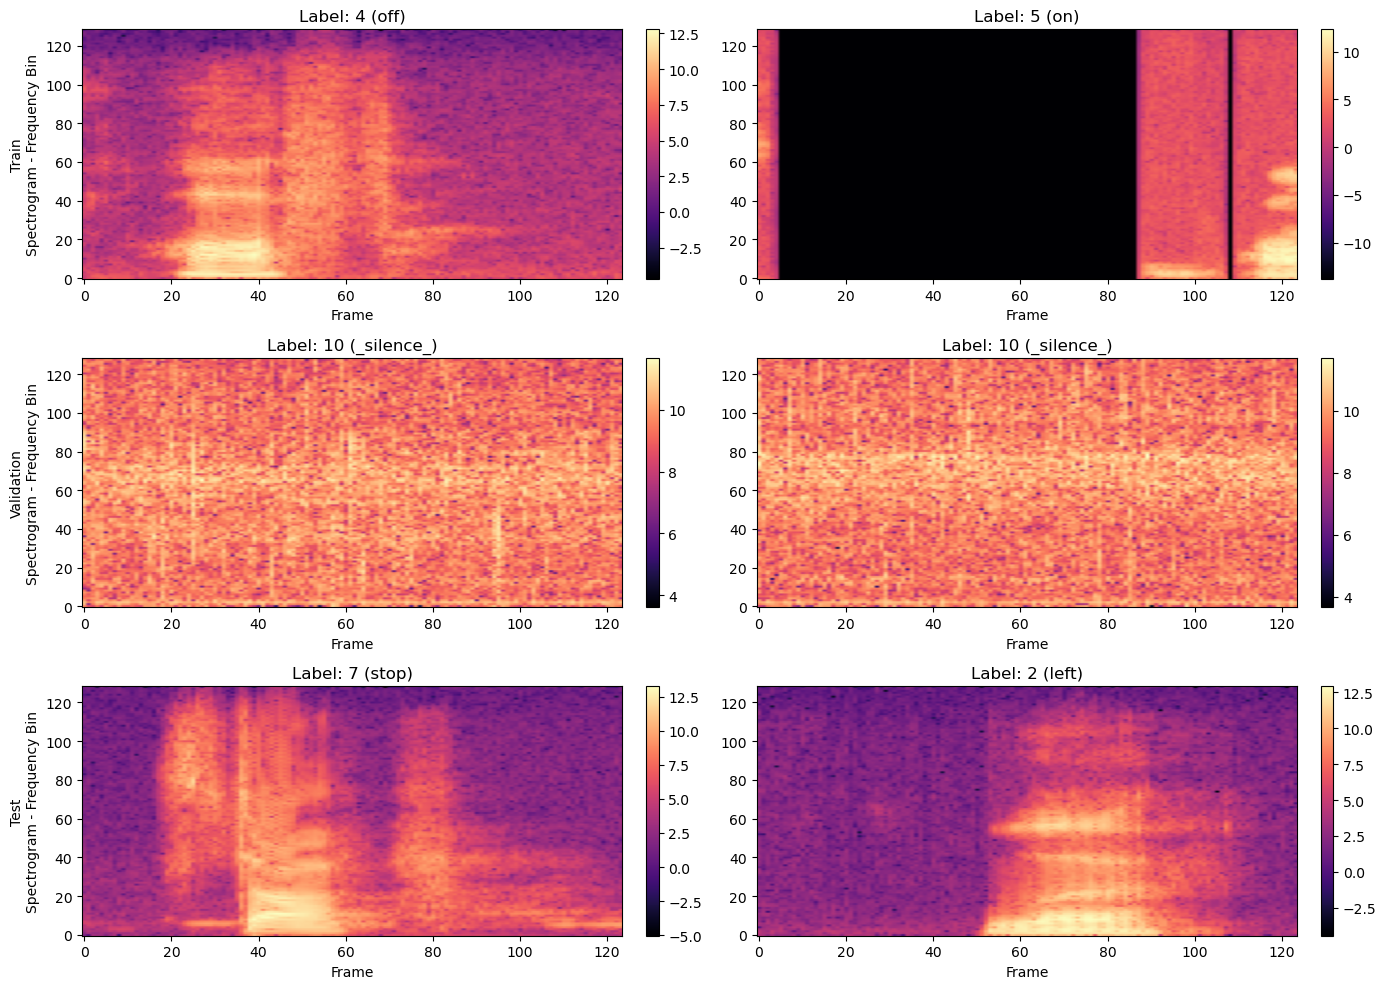

In [ ]:
# List of datasets to plot: (name, dataset)
datasets_to_plot = [
    ("Train", train_dataset),
    ("Validation", validation_dataset),
    ("Test", test_dataset)
]

fig, axs = plt.subplots(len(datasets_to_plot), 2, figsize=(14, 10))

def plot_spectrogram_on_ax(ax, spectrogram, label, label_names=None):
    im = ax.imshow(np.log(spectrogram.T + 1e-6), aspect='auto', origin='lower', cmap='magma')
    ax.set_xlabel('Frame')
    ax.set_ylabel('Frequency Bin')
    title = f"Label: {label}"
    if label_names is not None:
        title += f" ({label_names[label]})"
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for row, (name, dataset) in enumerate(datasets_to_plot):
    for col, (audio, label) in enumerate(dataset.take(2)):
        spectrogram = get_spectrogram(audio)
        plot_spectrogram_on_ax(axs[row, col], spectrogram.numpy(), label.numpy(), label_names)
        if col == 0:
            axs[row, col].set_ylabel(f"{name}\nSpectrogram - Frequency Bin")
        else:
            axs[row, col].set_ylabel("")

plt.tight_layout()
plt.show()


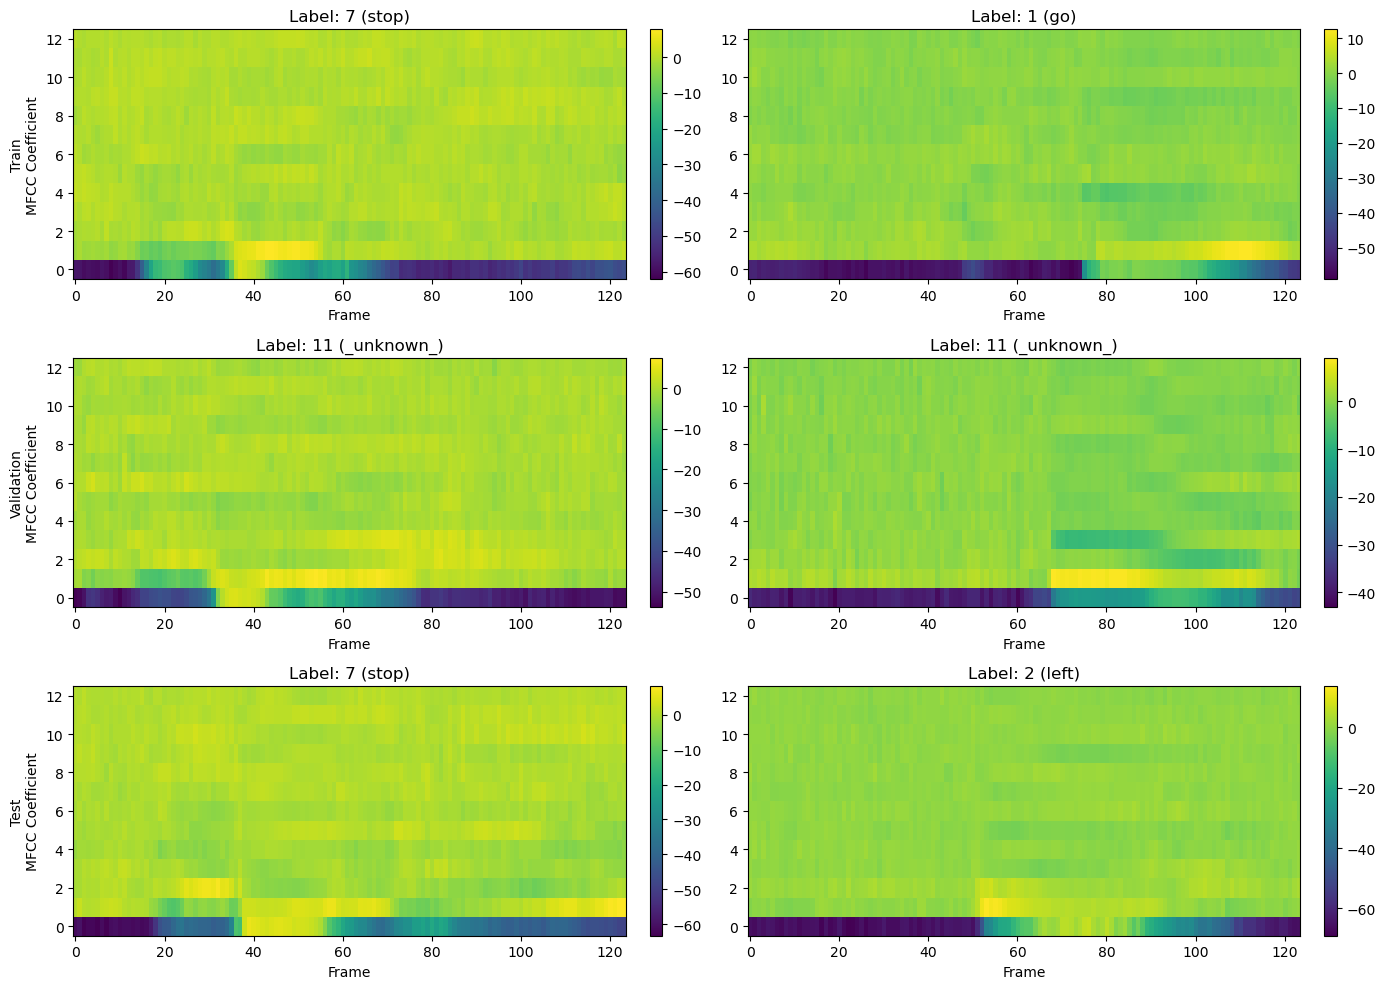

In [ ]:

fig, axs = plt.subplots(3, 2, figsize=(14, 10))

# Helper to plot MFCCs in a given axis
def plot_mfcc_on_ax(ax, mfccs, label, label_names=None):
    im = ax.imshow(mfccs.T, aspect='auto', origin='lower', cmap='viridis')
    ax.set_xlabel('Frame')
    ax.set_ylabel('MFCC Coefficient')
    title = f"Label: {label}"
    if label_names is not None:
        title += f" ({label_names[label]})"
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Plot 2 samples from each dataset
datasets = [
    ("Train", train_dataset_preprocessed),
    ("Validation", validation_dataset_preprocessed),
    ("Test", test_dataset_preprocessed)
]

for row, (name, ds) in enumerate(datasets):
    for col, (mfccs, label) in enumerate(ds.take(2)):
        plot_mfcc_on_ax(axs[row, col], mfccs.numpy(), label.numpy(), label_names)
        if col == 0:
            axs[row, col].set_ylabel(f"{name}\nMFCC Coefficient")
        else:
            axs[row, col].set_ylabel("")

plt.tight_layout()
plt.show()

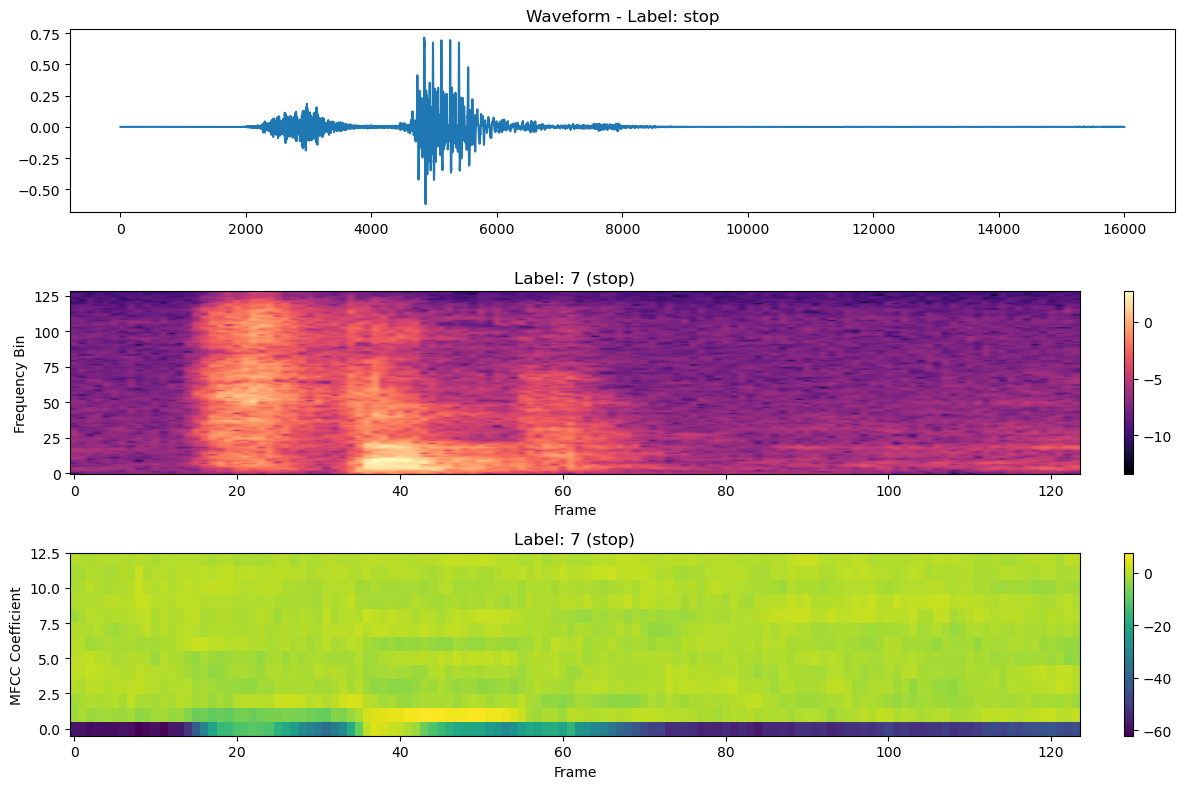

In [ ]:
preprocessed_audio, preprocessed_label = next(iter(train_dataset_Nor_Padded))
fig, axes = plt.subplots(3, figsize=(12, 8))

# Plot waveform
axes[0].plot(preprocessed_audio.numpy())
axes[0].set_title(f"Waveform - Label: {label_names[preprocessed_label.numpy()]}")

# Plot spectrogram
spectrogram = get_spectrogram(preprocessed_audio)
plot_spectrogram_on_ax(axes[1], spectrogram.numpy(), preprocessed_label.numpy(), label_names)

# Plot MFCC (use the same audio and label)
mfcc_audio, _ = extract_mfcc(preprocessed_audio, preprocessed_label)
plot_mfcc_on_ax(axes[2], mfcc_audio.numpy(), preprocessed_label.numpy(), label_names)

plt.tight_layout()
plt.show()

### Data preparation
the output shape of the Conv2D layer, such as (None, 119, 11, 32), has four dimensions because Conv2D in Keras expects and produces 4D tensors:

The first dimension (None) is the batch size (number of samples processed at once; None means it can be any size).

The second dimension (119) is the height (number of frames in your MFCC input after convolution).

The third dimension (11) is the width (number of MFCC coefficients after convolution).

The fourth dimension (32) is the number of filters (channels) produced by the Conv2D layer.

This 4D shape is standard for Conv2D layers in Keras/TensorFlow, where the input and output are always (batch, height, width, channels). The extra dimension (channels/filters) allows the network to learn multiple feature maps from the input.

Adding 1 channel and chossing a batch for training

In [8]:
# Check shape of a sample
for mfcc, _ in train_dataset_preprocessed.take(1):
    print(mfcc.shape)  # If (frames, 13), you need to add channel dim
    
def add_channel_dim(mfcc, label):
    mfcc = tf.expand_dims(mfcc, -1)
    return mfcc, label
# Only map if needed
if len(mfcc.shape) == 2:
    train_dataset_preprocessed = train_dataset_preprocessed.map(add_channel_dim)
    validation_dataset_preprocessed = validation_dataset_preprocessed.map(add_channel_dim)
    test_dataset_preprocessed = test_dataset_preprocessed.map(add_channel_dim)

# Batch, shuffle, and prefetch the datasets
# Prepare the datasets for training 
BATCH_SIZE = 32
train_dataset_batched = train_dataset_preprocessed.batch(BATCH_SIZE).shuffle(10000).prefetch(tf.data.AUTOTUNE)
validation_dataset_batched = validation_dataset_preprocessed.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset_batched = test_dataset_preprocessed.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

(124, 13)


In [9]:
print("train_dataset_batched dimention:", next(iter(train_dataset_batched))[0].shape)  # Should be (121, 13, 1)
print("validation_dataset_batched dimention:", next(iter(validation_dataset_batched))[0].shape)  # Should be (121, 13, 1)
print("test_dataset_batched dimention:", next(iter(test_dataset_batched))[0].shape)  # Should be (121, 13, 1)

train_dataset_batched dimention: (32, 124, 13, 1)
validation_dataset_batched dimention: (32, 124, 13, 1)
test_dataset_batched dimention: (32, 124, 13, 1)


Check out dimentions

In [ ]:
for x, y in train_dataset_batched.take(1):
    print("Train batch shape:", x.shape, y.shape)
for x, y in validation_dataset_batched.take(1):
    print("Validation batch shape:", x.shape, y.shape)
for x, y in test_dataset_batched.take(1):
    print("Test batch shape:", x.shape, y.shape)
# x refers to the batch of input features (MFCCs with shape (batch_size, frames, coefficients, channels)).
# y refers to the batch of labels (typically shape (batch_size,), containing the class indices for each sample in the batch).

Train batch shape: (32, 124, 13, 1) (32,)
Validation batch shape: (32, 124, 13, 1) (32,)
Test batch shape: (32, 124, 13, 1) (32,)


inspect batches:

In [ ]:
# Inspect the first 3 batches from each dataset
for name, dataset in [("Train", train_dataset_batched), 
                      ("Validation", validation_dataset_batched), 
                      ("Test", test_dataset_batched)]:
    print(f"\n{name} dataset:")
    for i, (x, y) in enumerate(dataset.take(3)):
        print(f"  Batch {i+1}: x.shape = {x.shape}, y.shape = {y.shape}, unique labels = {tf.unique(y)[0].numpy()}")


Train dataset:
  Batch 1: x.shape = (32, 124, 13, 1), y.shape = (32,), unique labels = [ 2 11  8  9  0  3  1]
  Batch 2: x.shape = (32, 124, 13, 1), y.shape = (32,), unique labels = [11  4  1  5  0]
  Batch 3: x.shape = (32, 124, 13, 1), y.shape = (32,), unique labels = [11  9  7  8  5 10]

Validation dataset:
  Batch 1: x.shape = (32, 124, 13, 1), y.shape = (32,), unique labels = [11  6  2  4  3  1  0  8  9]
  Batch 2: x.shape = (32, 124, 13, 1), y.shape = (32,), unique labels = [11  9 10  5  1  0  6  3  7]
  Batch 3: x.shape = (32, 124, 13, 1), y.shape = (32,), unique labels = [ 4  6 11  5  7  9  3  0  2]

Test dataset:
  Batch 1: x.shape = (32, 124, 13, 1), y.shape = (32,), unique labels = [ 7  2  6  8  5  0  9  4  3 11  1 10]
  Batch 2: x.shape = (32, 124, 13, 1), y.shape = (32,), unique labels = [ 6  7  5  9  1  8 11  2  3  0 10  4]
  Batch 3: x.shape = (32, 124, 13, 1), y.shape = (32,), unique labels = [ 9  3  1  7  5  8  0 10  4 11  2]


### 3: **Find a CNN for Keyword Spotting**

3.1 The next step is to identify a Convolutional Neural Network (CNN) architecture suitable for keyword spotting. A commonly used model for this task is based on the paper ["Convolutional Neural Networks for Small-footprint Keyword Spotting"](https://static.googleusercontent.com/media/research.google.com/en//pubs/archive/43969.pdf). This model is lightweight and designed for resource-constrained devices like microcontrollers.
 **Define the CNN Model**:
   - Use TensorFlow/Keras to define the CNN architecture.
   - compile - fit the model
   - Specify the optimizer, loss function, and evaluation metrics.




---

Try to optimize KWS model with the help of hyperparameters for microcontroller deployment. goal is to balance:

✅ High accuracy

✅ Low model size

✅ Low inference latency

✅ Low memory and power usage


In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from keras_tuner import RandomSearch
import time
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Get MFCC shape from a sample
example_mfcc_shape = next(iter(train_dataset_preprocessed.take(1)))[0].shape  # (121, 13)
input_shape = (example_mfcc_shape[0], example_mfcc_shape[1], 1)
# (121, 13, 1) to make the MFCC feature input compatible with Keras Conv2D layers, which expect a 3D input per sample: (height, width, channels)
num_classes = 12  # Set to number of labels
print(input_shape)  # Should be (121, 13, 1)
for batch in train_dataset_batched.take(1):
    print("Input batch shape:", batch[0].shape)


## Define input and output shape based on your MFCC features
#input_shape = (121, 13, 1)  # Example MFCC shape
num_classes = 12            # Number of output classes for KWS

# Build model function with tunable hyperparameters
def build_model(hp):
    model = models.Sequential()
    model.add(layers.Input(shape=input_shape))

    # First Conv2D layer
    model.add(layers.Conv2D(
        filters=hp.Choice('filters_1', values=[8, 16, 32]),
        kernel_size=(3, 3),
        activation='relu'))
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Optional second Conv2D layer. means that Keras Tuner will try both possibilities /
    #  use_second_conv = True (add a second Conv2D + MaxPooling2D layer)/
    #  use_second_conv = False (do not add them)
    if hp.Boolean('use_second_conv'):
        model.add(layers.Conv2D(
            filters=hp.Choice('filters_2', values=[16, 32, 64]),
            kernel_size=(3, 3),
            activation='relu'))

        model.add(BatchNormalization())
        model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Dropout layer (conv block)
    model.add(layers.Dropout(rate=hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)))

    model.add(layers.GlobalAveragePooling2D())

    # Fully connected layer
    model.add(layers.Dense(
        units=hp.Int('dense_units', min_value=32, max_value=128, step=32),
        activation='relu'))

    model.add(layers.Dropout(rate=hp.Float('dropout_fc', min_value=0.1, max_value=0.5, step=0.1)))

    # Output layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    # Optimizer
    lr = hp.Choice('learning_rate', [0.01])
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Define the tuner

tuner = RandomSearch(
    build_model,
    objective='val_accuracy', # Objective to optimize
    max_trials=10,  # Number of different hyperparameter combinations to try
    executions_per_trial=1, # Number of times to train each model with the same hyperparameters
    directory='kws_tuning', # Directory to save tuner results
    overwrite=True, # Overwrite previous results    
    project_name='cnn_mfcc_kws' # Project name for the tuner
)

# Add early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5, # Number of epochs with no improvement after which training will be stopped
    min_delta=0.01, # Minimum change in the monitored quantity to qualify as an improvement      
    verbose=1,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5, # Factor by which the learning rate will be reduced
    patience=2, # Number of epochs with no improvement after which learning rate will be reduced
    min_delta=0.01,
    min_lr=1e-6,
    verbose=1
)
# Begin tuning search
start = time.time()
tuner.search(
    train_dataset_batched,
    validation_data=validation_dataset_batched,
    epochs=20,
    callbacks=[early_stop, reduce_lr], # Add early stopping and learning rate reduction
    verbose=2
)
print(f"Tuning finished in {time.time() - start:.2f} seconds")

# Retrieve best model and hyperparameters
best_model = tuner.get_best_models(1)[0]
best_hps = tuner.get_best_hyperparameters(1)[0]

print("\nBest Hyperparameters:")
for param in best_hps.values:
    print(f"{param}: {best_hps.get(param)}")

# Print model summary and parameter count
best_model.summary()
print(f"\nTotal trainable parameters: {best_model.count_params()}")     

Trial 10 Complete [00h 16m 19s]
val_accuracy: 0.9320187568664551

Best val_accuracy So Far: 0.9320187568664551
Total elapsed time: 02h 07m 02s
Tuning finished in 7622.34 seconds



Best Hyperparameters:
filters_1: 32
use_second_conv: True
dropout_rate: 0.1
dense_units: 64
dropout_fc: 0.30000000000000004
learning_rate: 0.01
filters_2: 64
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 122, 11, 32)       320       
                                                                 
 batch_normalization (Batch  (None, 122, 11, 32)       128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 61, 5, 32)         0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 59, 3, 64)         18496     
                                                                 
 batch_normalization_1 (Bat  


3.2: Train the Model

We will train the model using the model.fit() method and validate it on the validation dataset.



In [12]:
history = best_model.fit(
    train_dataset_batched,
    validation_data=validation_dataset_batched,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
2996/2996 [==============================] - 48s 12ms/step - loss: 0.2658 - accuracy: 0.9172 - val_loss: 0.2256 - val_accuracy: 0.9295 - lr: 0.0012
Epoch 2/20
2996/2996 [==============================] - 48s 12ms/step - loss: 0.2655 - accuracy: 0.9157 - val_loss: 0.2322 - val_accuracy: 0.9285 - lr: 0.0012
Epoch 3/20
2996/2996 [==============================] - ETA: 0s - loss: 0.2632 - accuracy: 0.9171
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0006249999860301614.
2996/2996 [==============================] - 48s 12ms/step - loss: 0.2632 - accuracy: 0.9171 - val_loss: 0.2310 - val_accuracy: 0.9289 - lr: 0.0012
Epoch 4/20
2996/2996 [==============================] - 47s 12ms/step - loss: 0.2556 - accuracy: 0.9180 - val_loss: 0.2262 - val_accuracy: 0.9331 - lr: 6.2500e-04
Epoch 5/20
2992/2996 [============================>.] - ETA: 0s - loss: 0.2553 - accuracy: 0.9184
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003124999930150807.
2996/2996 [============

3.3 Evaluate the Model

Checks the shape of a test batch, MFCC sample.

Change needed? This is just for inspection.

In [13]:
for x, y in test_dataset_batched.take(1):
    print(x.shape, y.shape)

for mfcc, label in test_dataset_preprocessed.take(1):
    print(mfcc.shape)
    
# Evaluate the model on the test dataset
test_loss, test_accuracy = best_model.evaluate(test_dataset_batched)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


(32, 124, 13, 1) (32,)
(124, 13, 1)
153/153 [==============================] - 3s 15ms/step - loss: 0.3184 - accuracy: 0.8845
Test Loss: 0.3184
Test Accuracy: 0.8845


### 3.4 Metrics, Confusion Matrix and Visulisation

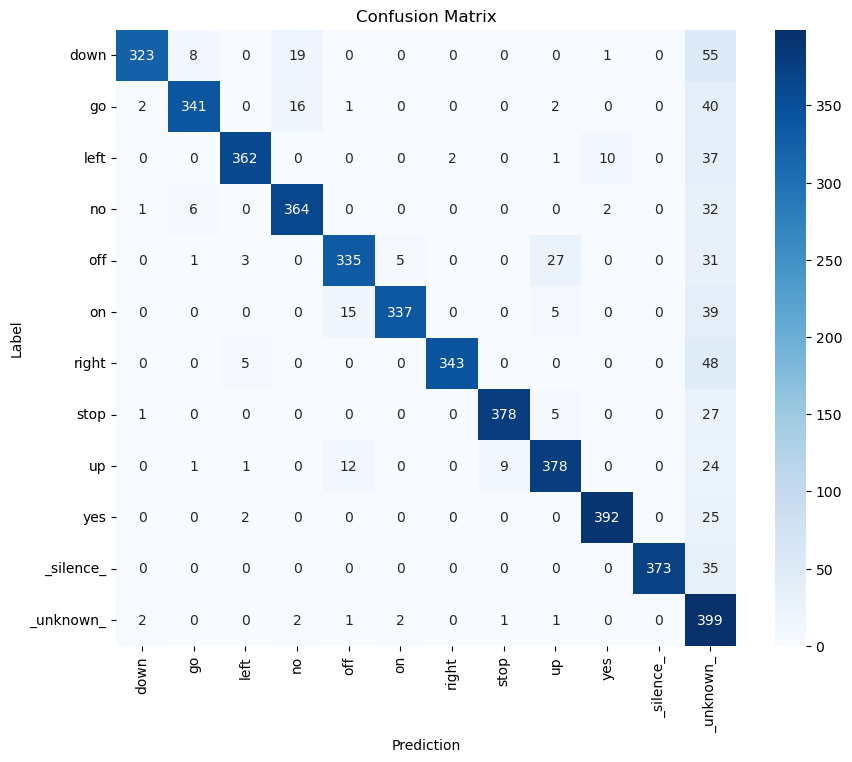


Classification Report:
              precision    recall  f1-score   support

        down       0.98      0.80      0.88       406
          go       0.96      0.85      0.90       402
        left       0.97      0.88      0.92       412
          no       0.91      0.90      0.90       405
         off       0.92      0.83      0.87       402
          on       0.98      0.85      0.91       396
       right       0.99      0.87      0.93       396
        stop       0.97      0.92      0.95       411
          up       0.90      0.89      0.90       425
         yes       0.97      0.94      0.95       419
   _silence_       1.00      0.91      0.96       408
   _unknown_       0.50      0.98      0.67       408

    accuracy                           0.88      4890
   macro avg       0.92      0.88      0.89      4890
weighted avg       0.92      0.88      0.89      4890



In [16]:
# Collect all test data and labels
X_test = []
y_true = []
for x, y in test_dataset_batched:
    X_test.append(x)
    y_true.extend(y.numpy())
X_test = np.concatenate(X_test, axis=0)
y_true = np.array(y_true)

# Predict all at once (no progress bar spam)
y_pred_probs = best_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Compute confusion matrix using TensorFlow
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)

# Plot confusion matrix as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=label_names,
            yticklabels=label_names,
            annot=True, fmt='g', cmap='Blues')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_names))

- Visualize Training Results

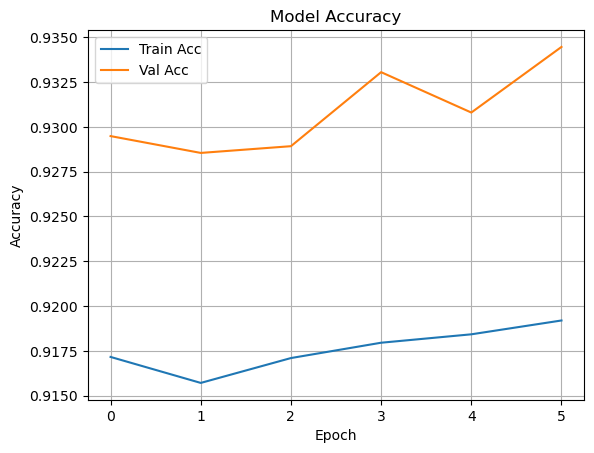

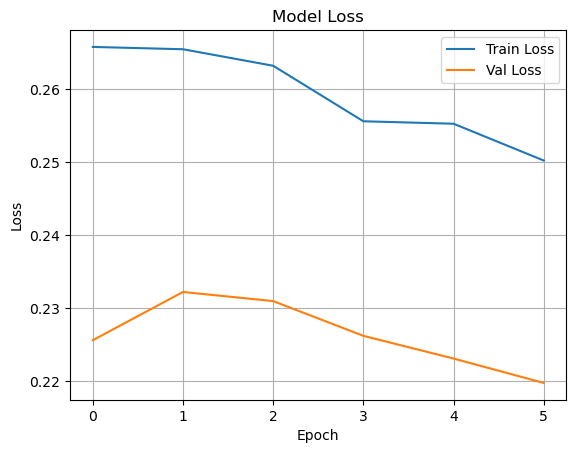

Training stopped after 6 epochs due to early stopping.
Best validation loss was at epoch 6.


In [17]:

# Accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.grid(True)
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')
plt.grid(True)
plt.show()

print(f"Training stopped after {len(history.history['loss'])} epochs due to early stopping.")
best_epoch = np.argmin(history.history['val_loss']) + 1  # +1 for 1-based indexing
print(f"Best validation loss was at epoch {best_epoch}.")

## 4: Post-Training Quantization

Post-training quantization is a crucial step to optimize the model for deployment on resource-constrained devices like the EFR32MG24 microcontroller. This process reduces the model size and improves inference speed by converting the model's weights from float32 to int8

### 4.1: Convert the Model to TensorFlow Lite Format

In [18]:
# Create a TFLiteConverter from your trained model
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)

# Convert the model to TFLite format (float32)
tflite_model = converter.convert()

# Save the TFLite model to a file
with open('model_float32.tflite', 'wb') as f:
    f.write(tflite_model)


INFO:tensorflow:Assets written to: C:\Users\Peyman\AppData\Local\Temp\tmp5bbqyo9x\assets


INFO:tensorflow:Assets written to: C:\Users\Peyman\AppData\Local\Temp\tmp5bbqyo9x\assets


### 4.2: Apply Post-Training Quantization

To quantize the model, we will use TensorFlow Lite's post-training quantization feature. This converts the weights to int8



In [19]:
# Apply post-training quantization with a representative dataset

def representative_data_gen():
    for audio, _ in train_dataset_Nor_Padded.take(100):  # Use 100 samples for calibration
        # Extract MFCCs as in training
        mfccs, _ = extract_mfcc(audio, _)
        mfccs = tf.expand_dims(mfccs, -1)  # Add channel dimension
        mfccs = tf.expand_dims(mfccs, 0)   # Add batch dimension
        yield [mfccs]

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_types = [tf.int8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

quantized_tflite_model = converter.convert()

with open('model_int8.tflite', 'wb') as f:
    f.write(quantized_tflite_model)

print("Model quantized to int8 and saved as 'model_int8.tflite'.")

INFO:tensorflow:Assets written to: C:\Users\Peyman\AppData\Local\Temp\tmp4tjrk4fn\assets


INFO:tensorflow:Assets written to: C:\Users\Peyman\AppData\Local\Temp\tmp4tjrk4fn\assets
c:\ProgramData\miniconda3\envs\kws6-env\lib\site-packages\tensorflow\lite\python\convert.py:953: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Model quantized to int8 and saved as 'model_int8.tflite'.


### 4.3: Verify the Quantized Model

To ensure the quantized model works as expected, we can test it by running inference on some test samples and comparing the results with the original model.

- inputs and ouputs both should be int8



In [20]:
import warnings
warnings.filterwarnings("ignore")

interpreter = tf.lite.Interpreter(model_path='model_int8.tflite')
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input dtype:", input_details[0]['dtype'])
print("Output dtype:", output_details[0]['dtype'])
print("Input shape:", input_details[0]['shape'])

Input dtype: <class 'numpy.int8'>
Output dtype: <class 'numpy.int8'>
Input shape: [  1 124  13   1]


- Checking more! Test Quantized Model on Samples

In [21]:
# Load the quantized model
interpreter = tf.lite.Interpreter(model_path='model_int8.tflite')
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Test the quantized model on a single test sample
for audio, label in test_dataset.take(10):
    # 1. Normalize
    audio = tf.cast(audio, tf.float32) / tf.int16.max
    # 2. Extract MFCCs
    mfccs, _ = extract_mfcc(audio, label)
    # 3. Add channel dimension
    mfccs = tf.expand_dims(mfccs, -1)
    # 4. Add batch dimension
    mfccs = tf.expand_dims(mfccs, 0)
    # 5. Quantize to int8 using input scale/zero_point
    input_scale, input_zero_point = input_details[0]['quantization']
    mfccs_int8 = np.round(mfccs.numpy() / input_scale + input_zero_point).astype(np.int8)
    # 6. Set tensor and run inference
    interpreter.set_tensor(input_details[0]['index'], mfccs_int8)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    print("Raw output:", output_data)
    print(f"Predicted: {tf.argmax(output_data[0])}, Actual: {label.numpy()}")

Raw output: [[-111 -128 -128 -128 -128 -126 -128 -118 -128 -128 -128   97]]
Predicted: 11, Actual: 7
Raw output: [[-128 -128 -128 -128 -127 -117 -128 -128  112 -128 -128 -124]]
Predicted: 8, Actual: 2
Raw output: [[-128 -128 -128 -128 -127 -117 -128 -128  112 -128 -128 -124]]
Predicted: 8, Actual: 6
Raw output: [[-127 -128 -128 -128 -128 -112 -128 -125 -101 -128 -128   80]]
Predicted: 11, Actual: 8
Raw output: [[-128 -128 -128 -128 -123   53 -128 -128  -63 -128 -128 -123]]
Predicted: 5, Actual: 5
Raw output: [[-128 -128 -128 -128 -128  123 -128 -128 -127 -128 -128 -124]]
Predicted: 5, Actual: 0
Raw output: [[-128 -128 -128 -128 -127 -126 -128 -128  124 -128 -128 -126]]
Predicted: 8, Actual: 8
Raw output: [[-127 -128 -128 -128 -128 -128 -128 -125 -128 -128 -128  124]]
Predicted: 11, Actual: 9
Raw output: [[-128 -128 -128 -128 -128 -128 -128 -128 -125 -128 -128  125]]
Predicted: 11, Actual: 4
Raw output: [[-128 -128 -128 -128 -127  -99 -128 -128   98 -128 -128 -128]]
Predicted: 8, Actual

### 4-4 Analyze model
- Open the link netron.app seperatly with an internet explorer and Open the model you created (model.tflite) by Model buttomn or "just run the following cell". Crate a image with the help of export as PNG in its menu. After saving the file as model.svg or model.png, place it in your current project folder.

In [22]:
import netron

# Opens a browser view
netron.start("model_int8.tflite")


('localhost', 8080)

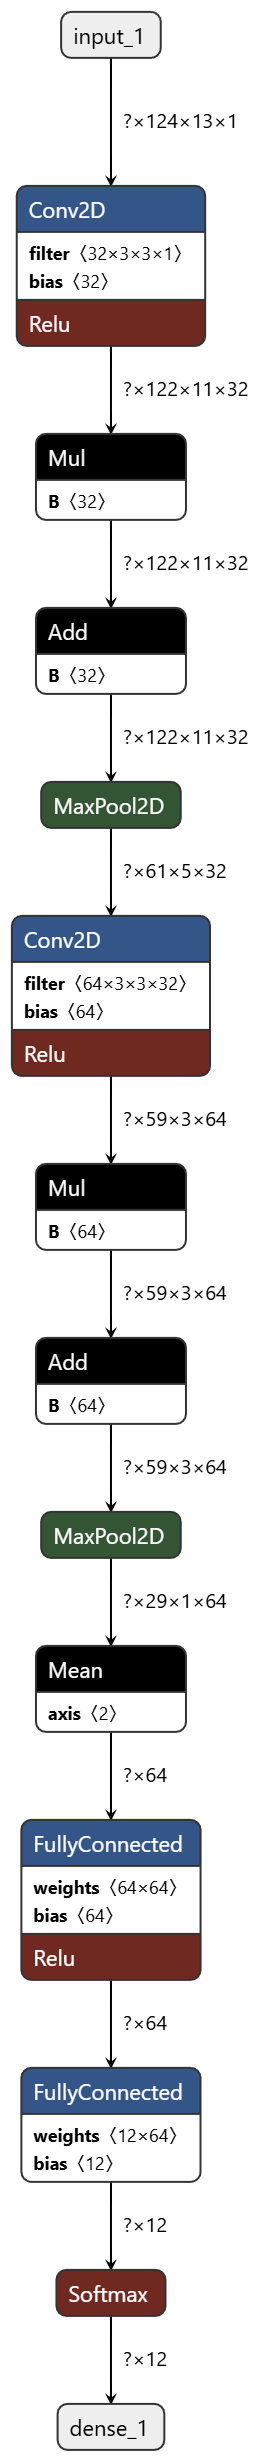

In [25]:
from IPython.display import Image, SVG
Image(filename="model_kws7.png")

- code-based summaries instead of visual diagram:

In [24]:

interpreter = tf.lite.Interpreter(model_path="model_int8.tflite")
interpreter.allocate_tensors()

for detail in interpreter.get_tensor_details():
    print(detail['name'], detail['shape'], detail['dtype'])


serving_default_input_1:0 [  1 124  13   1] <class 'numpy.int8'>
sequential/global_average_pooling2d/Mean/reduction_indices [2] <class 'numpy.int32'>
sequential/dense_1/BiasAdd/ReadVariableOp [12] <class 'numpy.int32'>
sequential/dense_1/MatMul [12 64] <class 'numpy.int8'>
sequential/dense/BiasAdd/ReadVariableOp [64] <class 'numpy.int32'>
sequential/dense/MatMul [64 64] <class 'numpy.int8'>
sequential/batch_normalization_1/FusedBatchNormV31 [64] <class 'numpy.int8'>
sequential/batch_normalization_1/FusedBatchNormV3 [64] <class 'numpy.int8'>
sequential/conv2d_1/BiasAdd/ReadVariableOp [64] <class 'numpy.int32'>
sequential/conv2d_1/Conv2D [64  3  3 32] <class 'numpy.int8'>
sequential/batch_normalization/FusedBatchNormV31 [32] <class 'numpy.int8'>
sequential/batch_normalization/FusedBatchNormV3 [32] <class 'numpy.int8'>
sequential/conv2d/BiasAdd/ReadVariableOp [32] <class 'numpy.int32'>
sequential/conv2d/Conv2D [32  3  3  1] <class 'numpy.int8'>
sequential/conv2d/Relu;sequential/conv2d/Bia